In [ ]:
def function3(input3):
    return input3

def function1(state):
    message = state["message"]
    return {"message": message + " from first function"}

def function2(state):  
    output = function3("this is function 3 in betweeen") 
    return {"message": state["message"] + " " + output + " and me from second function"}


In [8]:
from langgraph.graph import StateGraph, START, END

In [41]:
from typing import TypedDict

In [42]:
class AgentState(TypedDict):
    message: str

In [43]:
workflow = StateGraph(AgentState)
workflow.add_node("function1", function1)    

In [44]:

workflow.add_node("function2",function2)

In [45]:
workflow.add_edge("function1","function2")

In [46]:

workflow.set_entry_point("function1")

In [47]:
workflow.set_finish_point("function2")

In [48]:
app1=workflow.compile()

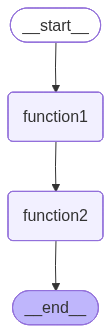

In [49]:

from IPython.display import Image, display

try:
    display(Image(app1.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [50]:
app1.invoke({"message": "hi this is satyam"})

{'message': 'hi this is satyamfrom first function this is function 3 in betweeen and me from second function'}

In [53]:
input = {
    "message": "hi this is satyam"
}

In [54]:
for output in app1.stream(input):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from function1
_______
{'message': 'hi this is satyamfrom first function'}


here is output from function2
_______
{'message': 'hi this is satyamfrom first function this is function 3 in betweeen and me from second function'}




LANGGRAPH USING LLM

In [11]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [1]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
llm.invoke("hi").content

C:\Users\ssaty\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'Hi there! How can I help you today?'

In [3]:
from typing import TypedDict

In [4]:
class LLMState(TypedDict):
    message: str

In [5]:
def function1(state):

    response = llm.invoke(state["message"]).content

    return {
        "message": response
    }

In [15]:
def function2(state):
    upper_message = state["message"].upper()
    return {
        "message": upper_message
    }

In [16]:
builder = StateGraph(LLMState)

builder.add_node("llm", function1)

builder.add_node("upper_string", function2)
builder.add_edge("llm", "upper_string")
builder.set_entry_point("llm")
builder.set_finish_point("upper_string") 
app2 = builder.compile()



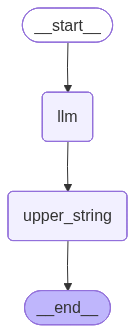

In [17]:
from IPython.display import Image, display

try:
    display(Image(app2.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [18]:
result = app2.invoke({
    "message": "who is the current prime minister of india ?"
})

In [19]:
print(result)

{'message': 'THE CURRENT PRIME MINISTER OF INDIA IS **NARENDRA MODI**.'}


In [20]:
def function3(state):
    message = state["message"]
    tokens = message.split()
    token_number = len(tokens)
    return {
        "message": message,
        "token_count": f"the number of tokens in the message are {token_number}"
    }

In [24]:
class AgentState(TypedDict):
    message: str
    token_count: str

In [25]:
workflow3 = StateGraph(AgentState)
workflow3.add_node("llm", function1)
workflow3.add_node("token_count", function3)
workflow3.add_edge("llm", "token_count")
workflow3.set_entry_point("llm")
workflow3.set_finish_point("token_count")
app3 = workflow3.compile()

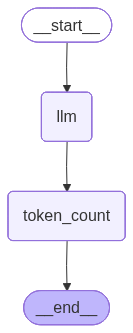

In [26]:

from IPython.display import Image, display

try:
    display(Image(app3.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [27]:
app3.invoke({
    "message": "who is the current prime minister of india ?"
})

{'message': 'The current Prime Minister of India is **Narendra Modi**.',
 'token_count': 'the number of tokens in the message are 9'}

LANGGRAPH USING RAG

In [57]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [58]:
loader=DirectoryLoader(r"C:\Users\ssaty\langgraph",glob="./*.txt",loader_cls=TextLoader)
docs=loader.load()
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=50
)
new_docs = text_splitter.split_documents(documents=docs)
doc_strings = [doc.page_content for doc in new_docs]

In [59]:
db = Chroma.from_documents(new_docs, embeddings)

retriever = db.as_retriever(search_kwargs={"k": 3})

In [31]:
query = "what is meta llama3?"

docs = retriever.invoke(query)

print(docs[0].metadata)
print(docs[0].page_content)

for doc in docs:
    print(doc)

{'source': 'C:\\Users\\ssaty\\langgraph\\llama3.txt'}
by Meta AI starting in February 2023.[2][3] The latest version is Llama 3 released in April
page_content='by Meta AI starting in February 2023.[2][3] The latest version is Llama 3 released in April' metadata={'source': 'C:\\Users\\ssaty\\langgraph\\llama3.txt'}
page_content='Llama (Large Language Model Meta AI) is a family of autoregressive large language models released by' metadata={'source': 'C:\\Users\\ssaty\\langgraph\\llama3.txt'}
page_content='Alongside the release of Llama 3, Meta added virtual assistant features to Facebook and WhatsApp in' metadata={'source': 'C:\\Users\\ssaty\\langgraph\\llama3.txt'}


In [60]:
def function_1(state):
    messages = state["messages"]
    question = messages[-1]
    
    complete_prompt = "Your task is to provide only the brief answer based on the user query. \
        Don't include too much reasoning. Following is the user query: " + question
    
    response = llm.invoke(complete_prompt)
    
    # Return a dict with only the updates to the state
    return {"messages": [response.content]}

In [61]:
class AgentState(TypedDict):
    messages: list[str]

In [62]:
# Create a state instance for testing
agent_state_instance = {"messages": []}

In [63]:
agent_state_instance

{'messages': []}

In [64]:
agent_state_instance["messages"].append("hi, how are you?")

In [65]:
agent_state_instance

{'messages': ['hi, how are you?']}

In [66]:
def function_2(state):
    messages = state['messages']
    question = messages[0]  # Fetching the user question

    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)

    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )
    result = retrieval_chain.invoke(question)
    
    # Return a dict with the updated messages
    return {"messages": [result]}

In [67]:

workflow4 = StateGraph(AgentState)
workflow4.add_node("LLM", function_1)
workflow4.add_node("RAGtool", function_2)
workflow4.add_edge('LLM', 'RAGtool')
workflow4.set_entry_point("LLM")
workflow4.set_finish_point("RAGtool")
app4 = workflow4.compile()

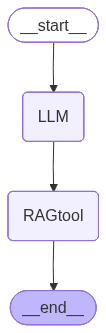

In [51]:
from IPython.display import Image, display

try:
    display(Image(app4.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [68]:
inputs = {"messages": ["Tell me about llama3 model"]}

In [69]:
for output in app4.stream(inputs):
    # stream() yields dictionaries with output keyed by node name
    for key, value in output.items():
        print(f"Output from node '{key}':")
        print("---")
        print(value)
    print("\n---\n")

Output from node 'LLM':
---
{'messages': ["Llama 3 is Meta's latest generation of open-source large language models, offering improved performance, various parameter sizes (e.g., 8B, 70B), and enhanced capabilities for a wide range of AI applications."]}

---

Output from node 'RAGtool':
---
{'messages': ['Based on the provided context, the statement is not fully supported.\n\nThe context states:\n*   "The latest version is Llama 3 released in April"\n*   Llama was "by Meta AI starting in February 2023."\n*   It mentions "other large language models" and "the original 13B parameter model\'s performance."\n\nHowever, the context **does not** mention:\n*   That Llama 3 is "open-source."\n*   That it offers "improved performance" (only mentions performance of a 13B model).\n*   "Various parameter sizes (e.g., 8B, 70B)" for Llama 3.\n*   "Enhanced capabilities for a wide range of AI applications."']}

---

